## CARD: Training Session 4

### Spatial discretization: Modeling a transient PFR

![PFR](./figures/session_4/example1.svg)

**Species conservation**:

$ \boxed{ \frac{dc_i}{dt} = -\frac{\delta c_i}{\delta z}u + \dot{r}_i }$

Leading to:

$ \boxed{ \frac{dc_{i,0}}{dt} = -\left( c_{i,0} - c_{i,\text{bc}} \right) \frac{u}{\Delta z L} + \dot{r}_i }$

$ \boxed{ \frac{dc_{i,1}}{dt} = -\left( c_{i,1} - c_{i,0} \right) \frac{u}{\Delta z L} + \dot{r}_i }$

$ \vdots $

$ \boxed{ \frac{dc_{i,n}}{dt} = -\left( c_{i,n} - c_{i,n-1} \right) \frac{u}{\Delta z L} + \dot{r}_i }$

**With the reaction kinetics**:

$ \boxed{ \dot{r}_i = \nu k c_i} $

**Implementation**:

- [NumPy](https://numpy.org/) for math and matrix operations
- [casADi](https://web.casadi.org/) to solve the DAE
- [Matplotlib](https://matplotlib.org/) with the module [pyplot](https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.html) to visualize the results

In [ ]:
import casadi as casADi
import matplotlib.pyplot as plt
import numpy as np


Setting the values and vector for the axial discretization:

In [2]:
n_axial = 10
delta_z = 1 / n_axial
z_c = np.arange(start=delta_z / 2, stop=1, step=delta_z)
print(z_c)

[0.05 0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.85 0.95]


Using an array as upper bound of the integral to calculate various timesteps:

In [3]:
t_0 = 0         # [s]
t_steps = 101   # [-]
t_end = 20      # [s]
t_i = np.linspace(t_0, t_end, t_steps)

Defining values of constant kinetic parameters:

In [4]:
k = 0.5         # [1/s]
nu = [-1, 1]    # [-]

Defining values of the reactor:

In [5]:
u = 0.1 # [m/s]
L = 1   # [m]

Now setting the initial and boundary conditions:

In [6]:
c_i_in = np.array([10, 0])  # [mol/m^3]
c_i_0 = np.array([10, 0])   # [mol/m^3]

Defining a 𝑚 × 𝑛 CasADi matrix $c_i$ containing all concentrations in each finite volume (n: number of components, m: number of finite volumes):

In [7]:
c_i = casADi.SX.sym("c_i", (n_axial, 2))

Defining the ODE system as 𝑚 × 𝑛 CasADi matrix by iterating through all components and  finite volumes using a *for* loop exluding the boundary condition:

In [8]:
ode = casADi.SX.sym("ode", (n_axial, 2))
for comp in range(len(nu)):
    for z in range(1, n_axial):
        ode[z, comp] = (
            -(c_i[z, comp] - c_i[z - 1, comp]) * u / (L * delta_z) +
            nu[comp] * c_i[z, 0] * k
            )

Defining ODE at the boundary:

In [9]:
z = 0
for comp in range(len(nu)):
    ode[z, comp] = (
        -(c_i[z, comp] - c_i_in[comp]) * u / (L * delta_z) + 
        nu[comp] * c_i[z, 0] * k
    )

Reshape the ODE and $c_i$ 𝑚 × 𝑛 CasADi matrix to a vector with 𝑚 × 𝑛 rows

In [10]:
c_i_reshaped = casADi.reshape(c_i, n_axial * len(nu), 1)
ode_reshaped = casADi.reshape(ode, n_axial * len(nu), 1)

Next a casADi specific dictionary is created with the following entries:

In [11]:
dae = {}
dae["x"] = c_i_reshaped
dae["ode"] = ode_reshaped

Then define and call the integrator to solve the DAE:

In [12]:
I = casADi.integrator("I", "idas", dae, t_0, t_i)
c_i_0_reshaped = np.zeros(n_axial * len(nu))
c_i_0_reshaped[0:n_axial] = c_i_0[0]
c_i_0_reshaped[n_axial:] = c_i_0[1]
res_dic = I(x0=c_i_0_reshaped)

Results are in matrix of 𝑚 × 𝑛 (m: number of all time-differential variables, n: timesteps) and need to be reshaped like this:

In [13]:
c_i_res = np.empty(shape=(n_axial, t_steps, len(nu)))
res_x = res_dic["xf"].full()
for t in range(t_steps):
    for comp in range(len(nu)):
        c_i_res[:, t, comp] = res_x[comp * n_axial : n_axial * (comp + 1), t]

Now calculate the conversion:

In [ ]:
X = (c_i_in[0] - c_i_res[-1, :, 0]) / c_i_in[0]

Plot the results:

Text(0.5, 0, '$t \\; \\mathregular{/s}$')

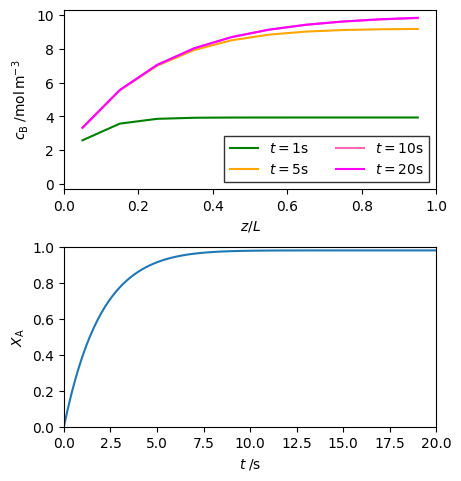

In [15]:
# Create figure and axes of plot
fig, axs = plt.subplots(2, 1, figsize=(4.5, 4.7), constrained_layout=True)

# Plot values
axs[0].plot(z_c, c_i_res[:, 5, 1], color="green", label=r"$t= 1 \mathregular{s}$")
axs[0].plot(z_c, c_i_res[:, 25, 1], color="orange", label=r"$t= 5 \mathregular{s}$")
axs[0].plot(z_c, c_i_res[:, 50, 1], color="hotpink", label=r"$t= 10 \mathregular{s}$")
axs[0].plot(z_c, c_i_res[:, 100, 1], color="magenta", label=r"$t= 20 \mathregular{s}$")

axs[1].plot(t_i, X)

# Set axes parameters
axs[0].set_ylim(np.min(c_i_in) - 0.3, np.max(c_i_in) + 0.3)
axs[0].set_xlim(0, 1)
axs[0].set_ylabel("$c_{\\mathregular{B}} \\; \\mathregular{/mol \\, m^{-3}}$")
axs[0].set_xlabel("$z/L$")
axs[0].legend(fancybox=False, loc="best", ncol=2, edgecolor="black")

axs[1].set_xlim(0, t_end)
axs[1].set_ylim(0, 1)
axs[1].set_ylabel("$X_{\\mathregular{A}}$")
axs[1].set_xlabel("$t \\; \\mathregular{/s}$")